In [123]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from arch import arch_model
from datetime import date
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Define the function to download the price and calculate the returns
Using logarithmic returns as they are more precise

In [124]:
def calculate_returns(ticker : str):
    today = date.today()
    df = yf.download(ticker, start="2015-01-01", end=today, auto_adjust=False)
    df["returns"] = np.log(df["Close"] / df["Close"].shift(1)) * 100
    df.dropna(inplace=True)
    return df

# Define the second function to fit the GARCH model and generate the forecast
we are using a t distribution (because the returns has a leptokurtic distribution) and using a GARCH(1,1) model

In [125]:
def predict_garch(X_test , y_train): 
    X_pred = []
    for i in range(len(X_test)):
        y_train_rolling = pd.concat([y_train, X_test.iloc[:i]])

        model = arch_model(y_train_rolling, vol="GARCH", p=1, q=1, dist="t")
        res = model.fit(disp="off")

        forecasts = res.forecast(horizon=1, reindex=False)
        predicted_variance = forecasts.variance.iloc[-1, 0]
        X_pred.append(np.sqrt(predicted_variance))
        
    predicted_volatility = pd.Series(X_pred, index= X_test.index)
    
    return predicted_volatility


Now select the ticker, this project uses yfinance, so we need to use the Yahoo Finance ticker and later define the cutoff (the quantity of days that we will predict)

In [126]:
ticker = "LDO.MI"
cutoff = -200

df = calculate_returns(ticker)
df.head()

[*********************100%***********************]  1 of 1 completed

Price,Adj Close,Close,High,Low,Open,Volume,returns
Ticker,LDO.MI,LDO.MI,LDO.MI,LDO.MI,LDO.MI,LDO.MI,
Date,,,,,,,
2015-01-05,6.565920,7.430,7.750,7.420,7.675,3513809,-3.958303
2015-01-06,6.495225,7.350,7.490,7.230,7.420,3659918,-1.082554
2015-01-07,6.596850,7.465,7.560,7.265,7.380,3378150,1.552515
2015-01-08,6.932658,7.845,7.885,7.520,7.610,4411096,4.965091
2015-01-09,6.760336,7.650,7.915,7.605,7.775,4187455,-2.517070


In [127]:
y_train = df["returns"][:cutoff]
X_test = df["returns"][cutoff:]
len(y_train)

2746

# Searching for correlation to justify using a GARCH model

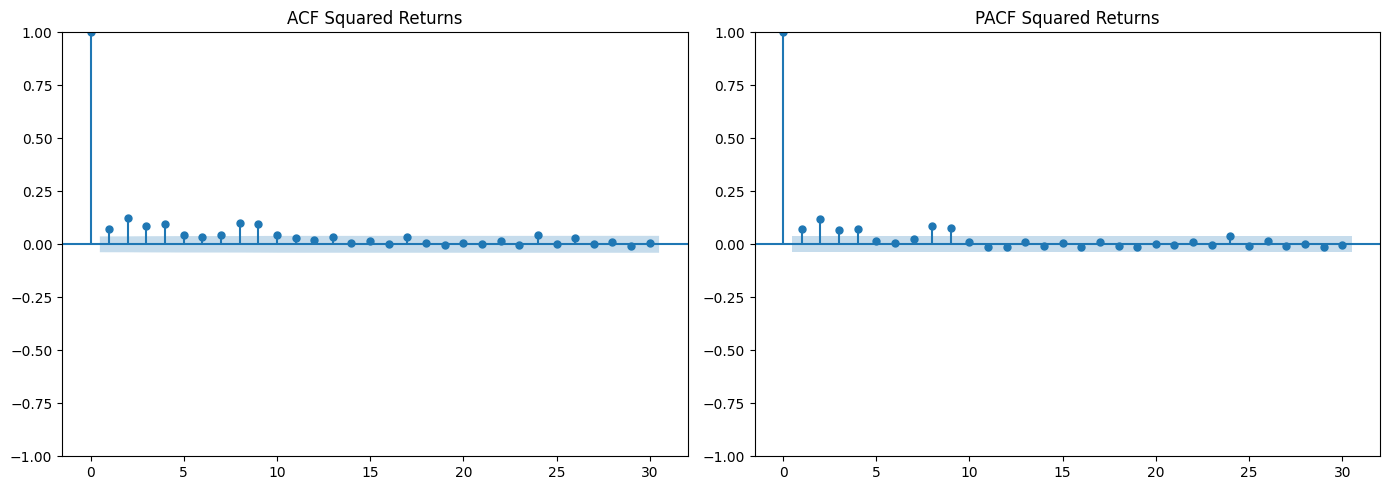

Date
2015-01-05    15.668162
2015-01-06     1.171922
2015-01-07     2.410303
2015-01-08    24.652127
2015-01-09     6.335641
                ...    
2025-10-14     0.637813
2025-10-15    18.411233
2025-10-16     1.507933
2025-10-17    29.827102
2025-10-20    17.922016
Name: returns, Length: 2746, dtype: float64

In [128]:
squared_returns = y_train ** 2
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_acf(squared_returns, lags=30, ax=axes[0], title="ACF Squared Returns")
plot_pacf(squared_returns, lags=30, ax=axes[1], title="PACF Squared Returns")
plt.tight_layout()
plt.show()
squared_returns

# Now it is time to evaluate the model
The model captured the conditional volatility 

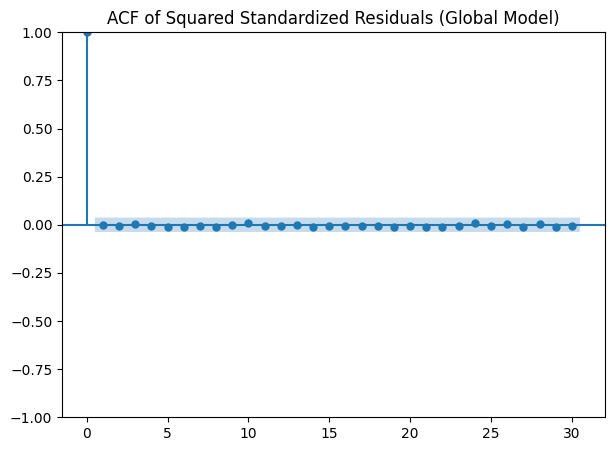

In [129]:
model_global = arch_model(y_train, vol="GARCH", p=1, q=1, dist="t")
results_global = model_global.fit(disp="off")
std_resid = results_global.resid / results_global.conditional_volatility
std_resid_squared = std_resid ** 2
std_resid_squared.dropna(inplace=True)

fig, ax = plt.subplots(figsize=(7, 5))
plot_acf(std_resid_squared, lags=30, ax=ax, title="ACF of Squared Standardized Residuals (Global Model)")
plt.show()

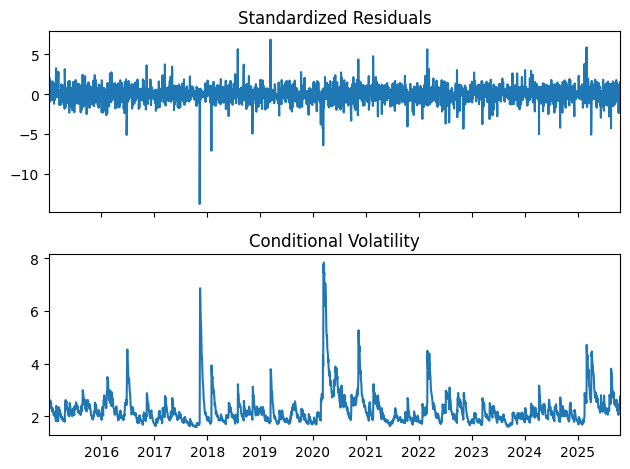

In [130]:
predicted_volatility = predict_garch(X_test=X_test, y_train=y_train)
fig = results_global.plot()
plt.tight_layout()
plt.show()

Comparing the real votality with the Predicted GARCH volatility

Note on Model Evaluation and Volatility Proxy

Absolute returns (abs(X_test)) are used to proxy true volatility. While standard for daily closing prices, it is a noisy estimator of a latent variable. With high-frequency data, Realized Volatility is the ideal metric to accurately capture intraday fluctuations. The current proxy is used due to the daily data frequency of Yahoo Finance.

Using other measures to evaluate the model like the Mean Absolute Error and the Mean Squared Error

In [131]:
mae = mean_absolute_error(abs(X_test), predicted_volatility)
rmse = np.sqrt(mean_squared_error(abs(X_test), predicted_volatility))
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

Mean Absolute Error (MAE): 1.4298
Root Mean Squared Error (RMSE): 1.7317


In [132]:

df['Naive_Vol_21d'] = df['returns'].shift(1).rolling(window=21).std()

naive_predicted_volatility = df['Naive_Vol_21d'][cutoff:]

naive_mae = mean_absolute_error(abs(X_test), naive_predicted_volatility)
naive_rmse = np.sqrt(mean_squared_error(abs(X_test), naive_predicted_volatility))

print(f"GARCH MAE: {mae:.4f}  |  Naive MAE: {naive_mae:.4f}")
print(f"GARCH RMSE: {rmse:.4f} |  Naive RMSE: {naive_rmse:.4f}")

GARCH MAE: 1.4298  |  Naive MAE: 1.5103
GARCH RMSE: 1.7317 |  Naive RMSE: 1.8080


### Model Evaluation and Conclusion

To evaluate the predictive power of our model, the GARCH(1,1) forecasts were compared against a standard baseline: a **Naive Model** (21-day rolling historical standard deviation). The evaluation metrics used are Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE).

| Metric | GARCH(1,1) | Naive Model (21d) |
| :--- | :---: | :---: |
| **MAE** | 1.4298 | 1.5103 |
| **RMSE** | 1.7317 | 1.8080 |

* Consistent Outperformance: The GARCH(1,1) model successfully outperforms the naive baseline across both error metrics. This confirms that modeling the conditional variance mathematically provides a tangible predictive advantage over simple historical averages
* Handling Volatility Spikes: The reduction in RMSE is particularly relevant in financial contexts. Since RMSE penalizes larger prediction errors more heavily, this lower value indicates that the GARCH model is significantly better at adapting to sudden volatility shocks (ARCH effects) than the lagging 21-day rolling window
* Practical Value: In financial econometrics, even seemingly small reductions in forecasting error are highly valuable. In real-world applications—such as Value at Risk (VaR) estimation or options pricing—this added precision translates into more accurate risk management and capital allocation

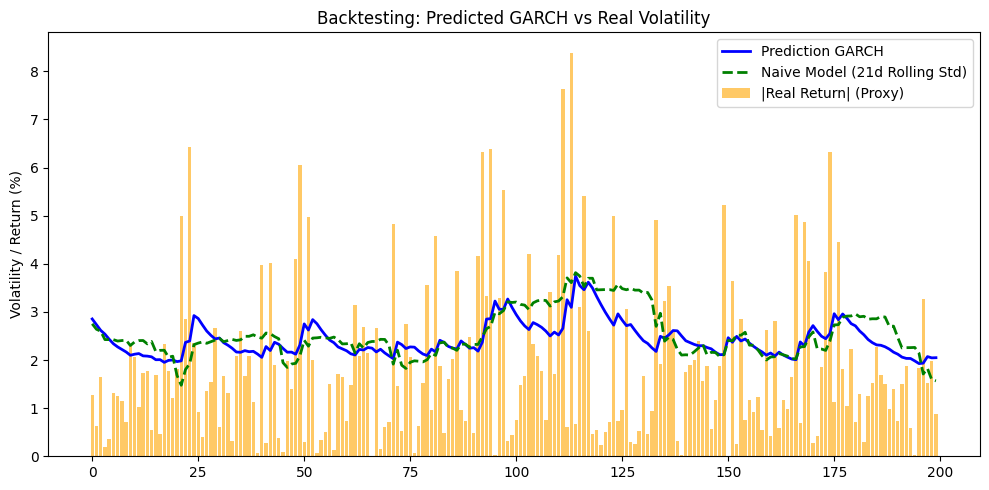

In [133]:
dates_str = range(cutoff * -1)

fig, ax = plt.subplots(figsize=(10, 5))


ax.plot(dates_str, predicted_volatility, 
        label='Prediction GARCH', color='blue', linewidth=2)
ax.plot(dates_str, naive_predicted_volatility, 
        label='Naive Model (21d Rolling Std)', color='green', linewidth=2, linestyle='--')
ax.bar(dates_str, abs(X_test), 
       label='|Real Return| (Proxy)', color='orange', alpha=0.6)

ax.set_title("Backtesting: Predicted GARCH vs Real Volatility")
ax.set_ylabel("Volatility / Return (%)")
ax.legend()
plt.tight_layout()
plt.show()